# Selenium

## Introduction

Selenium is a library used for automating online tasks through python code and the web driver of the browser you want to use.

We will start importing necessary libraries to start the process. The library will be used to develop the code inside the environment of the webdriver downloaded from internet. The class *webdriver* to manage the webdriver and the *By* is necessary because `Selenium` stop using only find_all for searching elements.


In [ ]:
from selenium.webdriver.common.by import By

from selenium import webdriver

# Calling the class of the browser we want to use
with webdriver.Chrome() as driver:
    try:
        # Getting the page we want to scrape
        driver.get("https://makeseleniumeasy.com/")

        # This code is used to wait for any object in case it is not loaded.
        # Suppose we execute a JavaScript code, and it is not loaded yet or something else.
        # It will always wait 10 seconds before looking for an element
        driver.implicitly_wait(10)

        # To obtain an element from the HTML code using `find_element` method followed by `By`
        # and the type of the selector:
        element = driver.find_element(
            By.XPATH,
            "//*[@id='node20']/div/div/div/div[1]/div/div[2]/p[3]/a[1]",
        )

        # Now clicking the element we should:
        element.click()
    finally:
        # Always close the driver to avoid leaking Chrome processes
        driver.quit()

ProtocolError: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))

### Locator Strategies with `By`

Here is a list of the most common locator strategies used with `find_element`:

| Method                   | Description                                    | Example                                                  |
|:-------------------------|:-----------------------------------------------|:---------------------------------------------------------|
| **By.ID**                | Locates elements by their ID attribute.        | `driver.find_element(By.ID, "submit")`                   |
| **By.NAME**              | Locates elements by their NAME attribute.      | `driver.find_element(By.NAME, "search")`                 |
| **By.XPATH**             | Locates elements using an XPath expression.    | `driver.find_element(By.XPATH, "//button")`              |
| **By.LINK_TEXT**         | Locates anchor elements by their visible text. | `driver.find_element(By.LINK_TEXT, "Home")`              |
| **By.PARTIAL_LINK_TEXT** | Locates anchor elements by a partial match.    | `driver.find_element(By.PARTIAL_LINK_TEXT, "Hom")`       |
| **By.TAG_NAME**          | Locates elements by their tag name.            | `driver.find_element(By.TAG_NAME, "a")`                  |
| **By.CLASS_NAME**        | Locates elements by their class name.          | `driver.find_element(By.CLASS_NAME, "btn-primary")`      |
| **By.CSS_SELECTOR**      | Locates elements using a CSS selector.         | `driver.find_element(By.CSS_SELECTOR, "#main .content")` |

More content in the pag 219 of the book `Web Scrapping`

More methods of `Selenium`:
- `.click_and_hold()`
- `.release()`
- `.double_click()`
- `.send_keys_to_element('content to enter')`

To be able to host all the actions in a variable we can do it in the following way following method 2:


In [ ]:
from selenium.webdriver import ActionChains
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys

from selenium import webdriver

driver = webdriver.Chrome()

with driver:
    ############
    driver.get("https://pythonscraping.com/pages/files/form.html")

    firstname_field = driver.find_element(By.NAME, "firstname")
    lastname_field = driver.find_element(By.NAME, "lastname")
    submit_button = driver.find_element(By.ID, "submit")

    # METHOD 1

    firstname_field.send_keys("John")
    lastname_field.send_keys("Mitchell")
    submit_button.click()

    print(driver.find_element(By.TAG_NAME, "body").text)

    ############
    driver.get("https://pythonscraping.com/pages/files/form.html")

    firstname_field = driver.find_element(By.NAME, "firstname")
    lastname_field = driver.find_element(By.NAME, "lastname")
    submit_button = driver.find_element(By.ID, "submit")

    # METHOD 2

    actions = (
        ActionChains(driver)
        .click(firstname_field)
        .send_keys("Ryan")
        .click(lastname_field)
        .send_keys("Mitchell")
        .send_keys(Keys.ENTER)
    )

    actions.perform()

    print(driver.find_element(By.TAG_NAME, "body").text)

    ############

Hello there, John Mitchell!
Hello there, Ryan Mitchell!


### Action Chains

With ActionChains we can execute a few actions in a row. Examples of this are:

```python
from selenium import webdriver
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys

driver = webdriver.Chrome()
driver.get("https://example.com")

element1 = driver.find_element(By.ID, "element1")
element2 = driver.find_element(By.NAME, "element2")
element3 = driver.find_element(By.XPATH, "//div[@id='element3']")
```

---

#### Actions

```python
actions = ActionChains(driver)
actions.click(element1)
actions.send_keys_to_element(element2, "Text example")
actions.context_click(element3)
actions.key_down(Keys.CONTROL).send_keys("a").key_up(Keys.CONTROL)
actions.perform()
```

### Waiting Strategies (Implicit vs Explicit)

The next libraries will help us to wait for an element to be loaded in the page before we can interact with it:

```python
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as ec
```

Also, we will bring two lines of code which will consist in waiting for an element to be loaded before interacting with it:

```python
WebDriverWait(driver, 50).until(
    ec.text_to_be_present_in_element(
        (By.XPATH, "//*[@id='navbar-collapse']/nav/ul/li[5]/a"),
        "Maven",
    ),
)
```

Also, we can use ec.visibility_of_element_located()

The last method only needs 1 parameter and the `text_to_be_present_in_element() needs at least 2 parameters, first the locator and second the text we are waiting to be loaded.`

---

```python
driver.get('http://pythonscraping.com/pages/javascript/ajaxDemo.html')

try:
    element = WebDriverWait(driver, 10).until(
        ec.presence_of_element_located((By.ID, 'loadedButton'))
    )
finally:
    print(driver.find_element_by_id('content').text)

driver.close()
```

The difference between the previous code and the one with driver.implicitly_wait() is that driver.implicitly_wait() waits for the page to load,
while the previous one waits for the object that is inside the page.

```python
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as ec

driver = webdriver.Chrome()

driver.get("https://www.seleniumeasy.com/")
driver.implicitly_wait(10)

element = driver.find_element(
    By.XPATH,
    "//*[@id='node20']/div/div/div/div[1]/div/div[2]/p[3]/a[1]",
)
element.click()

WebDriverWait(driver, 50).until(
    ec.text_to_be_present_in_element(
        (By.XPATH, "//*[@id='navbar-collapse']/nav/ul/li[5]/a"),
        "Maven",
    )
)
```

Also in the case we need to make some kind of authentication we can use the following code:

```python
# Replace url with the url + username:password@ example:
url = "https://example.com"
username = "your_username"
password = "your_password"

authenticated_url = url.replace("https://", f"https://{username}:{password}@")
driver.get(authenticated_url)
```

Now we can get the alert and send the text:

```python
alert.send_keys(username + Keys.TAB + password)
alert.accept()
```


##  Common Selenium Methods

```
.click() - Clicks on an element.
.send_keys() - Types text into an input field.
.get() - Navigates to a specified URL.
.find_element() - Finds a single element on the page.
.find_elements() - Finds multiple elements on the page.
.implicitly_wait() - Waits for a specified amount of time for elements to load.
.quit() - Closes the browser and ends the session.
```

## Comprehensive Exercise

We will increase the difficulty as we progress.

In the next exercise, we will create a class that inherits the methods from `webdriver.Chrome` and interacts with it.

All the following exercises will be developed within a Python package. This means we will create a folder named `Booking`, containing an `__init__.py` file. This allows us to import modules while outside the directory, for example using `import Booking.const`. The `__init__.py` file is only necessary when working with packages. We also have `run.py`, which is used to start the application.

The 3 exercises will be structured as follows:

```
project/
├── booking/
│   ├── __init__.py
│   ├── constants.py
│   ├── booking.py
├── run.py
```

`run.py` will call the booking class, which in turn will extract information from `constants`.

### Project Structure: run.py
This will be the script from which we will start everything.

It will be as follows:

We will start by extracting the `Booking` class from the `booking` module and the `booking` package that was created thanks to the `__init__.py` file.


## Advanced Techniques

We can use the `execute_script()` method to run JavaScript code within the context of the current page. This is useful for interacting with elements that may not be easily accessible through standard Selenium methods or for performing actions that require JavaScript.

```python
from selenium import webdriver

driver = webdriver.Chrome()
driver.get("https://example.com")
driver.execute_script("alert('Hello, World!')")
```

### Handling Redirects

A lot of time, we find us in a situation where we try to access a page, but it is not possible because it is being redirected to another page.

This happens because the page is being loaded with JavaScript, to avoid people to scrape the page.

To execute the JS code we can:


In [ ]:
from selenium.common.exceptions import TimeoutException
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as ec
from selenium.webdriver.support.ui import WebDriverWait

from selenium import webdriver


def wait_for_load(chrome_driver: webdriver.Chrome) -> None:
    # elem = driver.find_element(By.TAG_NAME, "html")
    # count = 0

    # while True:
    #     count += 1
    #     if count > 20:
    #         print("Timing out after 10 seconds and returning")
    #         return
    #     time.sleep(0.5)
    #     try:
    #         if elem != driver.find_element(By.TAG_NAME, "html"):
    #             print("Page was refreshed")
    #             return
    #     except StaleElementReferenceException:
    #         print("Exception raised, page was refreshed")
    #         return

    old_page = chrome_driver.find_element(By.TAG_NAME, "html")

    try:
        # WebDriverWait(chrome_driver, 10).until(
        #     ec.presence_of_element_located(
        #         (By.XPATH, "//body[contains(text(), 'This is the page you are looking for!')]")
        #     ),
        # )
        WebDriverWait(chrome_driver, 10).until(
            ec.staleness_of(old_page),
        )
        print("Page was refreshed")
    except TimeoutException:
        print("Timeout: page was not refreshed after 10 seconds")


driver = webdriver.Chrome()

with driver:
    driver.get("http://pythonscraping.com/pages/javascript/redirectDemo1.html")
    print(driver.find_element(By.TAG_NAME, "body").text)
    wait_for_load(driver)
    print(driver.find_element(By.TAG_NAME, "body").text)

This page will be redirecting soon...
Page was refreshed
This is the page you are looking for!


### Cookie Management (Basic)

To manage cookies with Selenium, you can use the following methods:

```python
cookies = driver.get_cookies() # Returns a list of all cookies in the current session.
cookie = driver.get_cookie("cookie_name") # Returns a specific cookie by name.
driver.add_cookie({"name": "cookie_name", "value": "cookie_value"}) # Adds a cookie to the current session.
driver.delete_cookie("cookie_name") # Deletes a specific cookie by name.
driver.delete_all_cookies() # Deletes all cookies in the current session.
```

### Showing Hidden Elements

We can show hidden elements (hidden with CSS) by executing the following JavaScript code:

```python
driver.execute_script("document.getElementById('hidden_element_id').style.display = 'block'")
```

### Drag and Drop

To perform a drag and drop action with Selenium, you can use the `ActionChains` class. Here's an example of how to do it:

```python
from selenium import webdriver
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.by import By

driver = webdriver.Chrome()
driver.get("https://example.com")
source_element = driver.find_element(By.ID, "source")
target_element = driver.find_element(By.ID, "target")
actions = ActionChains(driver)
actions.drag_and_drop(source_element, target_element).perform()
```

### Screenshots

To take a screenshot of the current page using Selenium, you can use the `save_screenshot()` method. Here's an example:

```python
from selenium import webdriver

driver = webdriver.Chrome()
driver.get("https://example.com")
driver.get_screenshot_as_file("tmp/pythonscraping.png")
```

## Undetected Selenium

In this case we will use a Selenium similar library and to access to `STRONG` anti-scraping systems (captcha, js code, robot.txt, header readers)

We should install the library with the following command:

```zsh
uv add undetected_chromedriver
```

To create a driver with this library we should do it in the following way:

```python
import undetected_chromedriver as uc

options = uc.Chrome()
```

### Chrome Options & Arguments

When we create a driver we can add some parameters to it to simulate a real human behavior as much as possible.

For that we can use the class `Options`, like in the following code:

```python
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

chrome_options = Options()
```

I'll next enumerate parameters ordering them by most importance to the least importance:

#### Avoid bots detection

| Option                                          | Effect                                                                                                        |
|:------------------------------------------------|:--------------------------------------------------------------------------------------------------------------|
| `--disable-blink-features=AutomationControlled` | Hides the flag navigator.webdriver, which is used by some websites to detect if the user is a bot.            |
| `--disable-infobars`                            | Deletes the "Chrome is being controlled by automated test software" infobar that appears when using Selenium. |
| `--user-agent="..."`                            | Define your own User-Agent.                                                                                   |

#### Appearance and window

| Option                              | Effect                                                 |
|:------------------------------------|:-------------------------------------------------------|
| `--start-maximized`                 | Opens the browser in maximized mode.                   |
| `--window-size=width,height`        | Opens the browser with a specific window size.         |
| `--window-position=x,y`             | Opens the browser at a specific position on the screen |
| `--headless=new` or `headless=True` | Runs the browser in headless mode (without a GUI).     |

#### Network and conexions

<!-- Create tables with Option and Effect -->
| Option                                | Effect                                                                                                                        |
|:--------------------------------------|:------------------------------------------------------------------------------------------------------------------------------|
| `--proxy-server-http=https://IP:PORT` | Sets a proxy server for HTTP requests.                                                                                        |
| `--no-proxy-server`                   | Disables the use of a proxy server.                                                                                           |
| `--proxy-bypass-list=...`             | Specifies a list of hosts that should bypass the proxy server. The list can include wildcards and is separated by semicolons. |
| `--ignore-certificate-errors`         | Ignores SSL certificate errors, which can be useful when scraping websites with self-signed certificates.                     |
| `--allow-insecure-localhost`          | Allows insecure connections to localhost, which can be useful for testing purposes.                                           |

### Cookie Management (Basic) and Privacy

| Option                     | Effect                                                                                |
|:---------------------------|:--------------------------------------------------------------------------------------|
| `--incognito`              | Opens the browser in incognito mode, which does not save browsing history or cookies. |
| `--disable-notifications`  | Disables browser notifications, which can be useful for testing purposes.             |
| `--disable-geolocation`    | Disables geolocation services, which can help to avoid detection by some websites.    |
| `--disable-extensions`     | Disables all browser extensions, which can help to avoid detection by some websites.  |
| `--disable-popup-blocking` | Disables the popup blocker, which can be useful for testing purposes.                 |

#### Performance and stability

| Option                                     | Effect                                                                                                                       |
|:-------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------|
| `--disable-gpu`                            | Disables GPU hardware acceleration, which can improve performance and stability on some systems.                             |
| `--disable-dev-shm-usage`                  | Disables the use of /dev/shm, which can help to avoid issues with limited shared memory in some environments (Docker/Linux). |
| `--no-sandbox`                             | Disables the sandbox, which can help to avoid sandbox restrictions.                                                          |
| `--disable-software-rasterizer`            | Disables the software rasterizer, which can improve performance on some systems.                                             |
| `--disable-background-timer-throttling`    | Disables background timer throttling, which can improve performance in some scenarios.                                       |
| `--disable-render-backgrounding`           | Disables rendering of background tabs, which can improve performance in some scenarios.                                      |
| `--disable-backgrounding-occluded-windows` | Disables backgrounding of occluded windows, which can improve performance in some scenarios.                                 |
| `--disable-extensions`                     | Disables all browser extensions, which can improve performance in some scenarios.                                            |
| `--no-first-run`                           | Skips the first run experience, which can improve performance on the first launch.                                           |
| `--no-default-browser-check`               | Skips the default browser check, which can improve performance on the first launch.                                          |

#### Data and profiles

| Option                            | Effect                                                                                                                    |
|:----------------------------------|:--------------------------------------------------------------------------------------------------------------------------|
| `--user-data-dir=path/to/profile` | Specifies a custom user data directory, which can be used to maintain separate profiles with different settings and data. |
| `--profile-directory=Profile 1`   | Specifies a specific profile directory within the user data directory to use.                                             |
| `--disk-cache-size=0`             | Disables disk caching, which can help to avoid issues with cached data.                                                   |

#### Developer and debugging

| Option                         | Effect                                                                                                       |
|:-------------------------------|:-------------------------------------------------------------------------------------------------------------|
| `--remote-debugging-port=9222` | Enables remote debugging on the specified port, allowing you to connect to the browser with developer tools. |
| `--enable-logging`             | Enables logging of browser events, which can be useful for debugging.                                        |
| `--disable-logging`            | Disables logging of browser events.                                                                          |
| `--log-level=0`                | Sets the logging level (0 = INFO, 1 = WARNING, 2 = ERROR, 3 = FATAL).                                        |

## Interactions & Navigation

Actions in Selenium are a way to simulate complex user interactions with web elements.

### Scrolling

There are two main methods to scroll a webpage using Selenium. Using `JavaScript` and using `ActionChains`.

With `JavaScript`:

`driver.execute_script("window.scrollTo(0, pixels)")` - Scroll down the page.\

With `ActionChains`:

```python
from selenium.webdriver.common.action_chains import ActionChains

actions = ActionChains(driver)
actions.move_to_element(element).perform()            # Scrolls to the specified element.
actions.move_by_offset(x_offset, y_offset).perform()  # Scrolls by a specific offset from the current position.
```

### Opening a New Window

To open a new window in Selenium, you can use the `execute_script()` method to run JavaScript code that opens a new window. Here's an example:

`driver.execute_script("window.open('url')")`

```python
from selenium import webdriver

driver = webdriver.Chrome()
driver.get("https://example.com")
driver.execute_script("window.open('https://www.google.com', '_blank')")  # Opens a new window with the specified URL.
```

### Switching Tabs
To switch between tabs in Selenium, you can use the `window_handles` property to get a list of all open windows and the `switch_to.window()` method to switch to a specific window.\
Here's an example:

#### Switching using loops

```python
for index, handle in enumerate(driver.window_handles):
    driver.switch_to.window(handle)
    html_text = driver.page_source
```

#### Switching using loops

We can use an indicator to switch to a specific tab, for example:

```python
window = driver.window_handles[2]

driver.switch_to.window(window)
```


## Comprehensive Cookie Management

Cookies are JSON-like files that store information about the user's interaction with the website.\
Some IMPORTANT data that we need to keep in mind about cookies:
* The most convenient thing is to add cookies right after going to the website.
* Cookies should always be edited. The value of the 'domain' key should always start with

### Obtain Cookies

To obtain cookies from a website using Selenium, you can use the `get_cookies()` method, which returns a list of all cookies in the current session.\
Here's an example:

```python
cookies = driver.get_cookies()
```

### Add Cookies

To add a cookie to the current session using Selenium, you can use the `add_cookie()` method. This method takes a dictionary representing the cookie you want to add.\
Here's an example:

```python
cookie = {"name": "cookie_name", "value": "cookie_value"}
driver.add_cookie(cookie)
```

Extracting information from trustpilot with Undetected Selenium


In [2]:
import json
import random
import time
from pathlib import Path

import undetected_chromedriver as uc
from selenium.common import MoveTargetOutOfBoundsException
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.action_chains import ActionChains

chrome_options = Options()
arguments = [
    # "--headless",
    "--disable-blink-features=AutomationControlled",
    "--start-maximized",
    "--disable-popup-blocking",
]

[chrome_options.add_argument(arg) for arg in arguments]

url_1 = "https://www.tripadvisor.es/Restaurant_Review-g580332-d5862706-Reviews-Rostisseria_Can_Padres-Pals_Costa_Brava_Province_of_Girona_Catalonia.html#REVIEWS"

urls = [
    "https://www.tripadvisor.es/Restaurant_Review-g580332-d5862706-Reviews-or300-Rostisseria_Can_Padres-Pals_Costa_Brava_Province_of_Girona_Catalonia.html",
    "https://www.tripadvisor.es/Restaurant_Review-g580332-d5862706-Reviews-or285-Rostisseria_Can_Padres-Pals_Costa_Brava_Province_of_Girona_Catalonia.html",
]

driver = uc.Chrome(options=chrome_options, version_main=144)

with driver:
    driver.maximize_window()
    driver.refresh()
    driver.get(url_1)

    # Adding cookies

    with Path("stuff.json").open("r", encoding="utf-8") as json_file:
        data_file = json.load(json_file)

        for item in data_file:
            print(item)
            driver.add_cookie(item)

    time.sleep(10)

    for url in urls:
        driver.execute_script("window.open(arguments[0], '_blank')", url)
        time.sleep(0.5)

    try:
        actions = ActionChains(driver)

        for _ in range(5):
            actions.move_by_offset(0, 200).perform()

            time.sleep(random.uniform(0.5, 1.5))
    except MoveTargetOutOfBoundsException as e:
        pass

    time.sleep(5)

    for item, handle in enumerate(driver.window_handles):
        driver.switch_to.window(handle)
        html_text = driver.page_source

        Path(f"trip_advisor_{item}.text").write_text(html_text, encoding="utf-8")

        window = driver.window_handles[2]
        driver.switch_to.window(window)

    data = driver.get_cookies()

    # for item in data:
    #     if not str(item["domain"]).startswith("."):
    #         item["domain"] = f".{item['domain']}"

    with Path("stuff.json").open("w", encoding="utf-8") as json_file:
        json.dump(data, json_file, indent=2)


{'name': 'example_cookie_name', 'value': 'example_cookie_value', 'domain': '.tripadvisor.es', 'path': '/'}


## Important Details to Keep in Mind
* Normally if there is an anti-scrapping block (captcha, etc.) when you bypass it and have some cookies saved that allow you to pass, you cannot use a request with HTMLSession or requests. You will be blocked.
* There are two ways to browse multiple tabs with undetected_chromedriver:
    * Open multiple tabs in a loop synchronously (not asynchronously) with JavaScript
    * Open with asyncio + ThreadPoolExecutor
* When opening multiple windows, there is a possibility that the browser will block that possibility by the website interpreting it as a pop-up with JavaScript using window.open().\
  To avoid that we can "try" (there will be times when it won't let us) to disable the pop-up blocking with chrome_options.add_argument("--disable-popup-blocking")
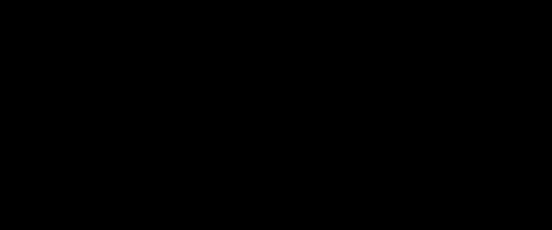
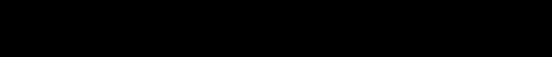
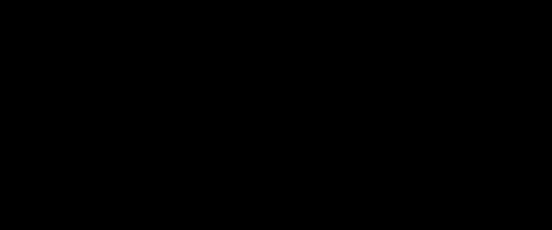
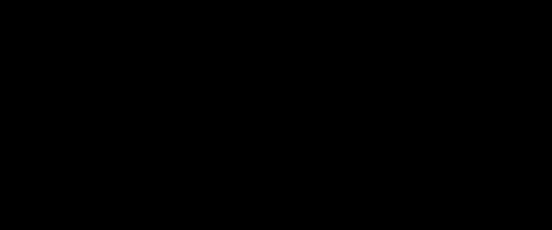

## Scrolling down using JS

Detect the elements which one have a scroll, capture them and scroll down. Inside `execute_async_script` we can use:

```javascript
const autoScroll = async (container = document.scrollingElement, pause = 800, maxRounds = 500) => {
  let lastHeight = 0

  for (let round = 0; round < maxRounds; round++) {
    container.scrollTo(0, container.scrollHeight)
    await new Promise(response => setTimeout(response, pause))

    const newHeight = container.scrollHeight
    console.log(`Round ${round + 1}: Scrolled to ${newHeight}px`)

    if (newHeight === lastHeight) {
      console.log('No more content to load. Stopping auto-scroll.')
      break
    }
    lastHeight = newHeight
  }
}

const findScrollableAncestor = () => {
  const elements = Array.from(document.querySelectorAll('body *'))

  for (const element of elements) {
    const style = getComputedStyle(element)

    if ((style.overflowY === 'auto' || style.overflowY === 'scroll') && element.scrollHeight > element.clientHeight) return element
  }

  return document.scrollingElement || document.documentElement
}

const container = findScrollableAncestor()

autoScroll(container).then(r => {})
```

In [1]:
from selenium import webdriver

driver = webdriver.Chrome()
driver.options("headless=False")

with driver:
    driver.get("")
    driver.set_script_timeout(300)
    driver.execute_async_script(
        """
            const callback = arguments[arguments.length - 1]
            const autoScroll = async (container = document.scrollingElement, pause = 800, maxRounds = 500) => {
              let lastHeight = 0

              for (let round = 0; round < maxRounds; round++) {
                container.scrollTo(0, container.scrollHeight)
                await new Promise(response => setTimeout(response, pause))

                const newHeight = container.scrollHeight
                console.log(`Round ${round + 1}: Scrolled to ${newHeight}px`)

                if (newHeight === lastHeight) {
                  console.log('No more content to load. Stopping auto-scroll.')
                  break
                }
                lastHeight = newHeight
              }
            }

            const findScrollableAncestor = () => {
              const elements = Array.from(document.querySelectorAll('body *'))

              for (const element of elements) {
                const style = getComputedStyle(element)

                if ((style.overflowY === 'auto' || style.overflowY === 'scroll') && element.scrollHeight > element.clientHeight) return element
              }

              return document.scrollingElement || document.documentElement
            }

            const container = findScrollableAncestor()

            autoScroll(container).then(r => {callback})
        """,
    )


TypeError: 'Options' object is not callable